In [1]:
import pandas as pd

In [ ]:
#df = pd.read_csv('PUBL_accuracy_results_m1_all_pairs.csv')
#df = pd.read_csv("PUBL_accuracy_results_m1_all_pairs_logprobs.csv")
df_summary = pd.read_csv("PUBL_accuracy_summary_all_pairs_m1_logprobs.csv") 

In [12]:
df_summary

,total_pairs,ab_mean_accuracy,ba_mean_accuracy,joint_mean_accuracy,ab_mean_confidence,ba_mean_confidence,ab_mean_logprob,ba_mean_logprob,avg_latency_per_pair_seconds,avg_latency_per_query_seconds,total_execution_time_seconds
0,108,0.842593,0.833333,0.837963,0.932547,0.929252,-0.000005,-0.000739,4.96,2.48,535.86


In [13]:
ab_accuracy = df_summary['ab_mean_accuracy'].iloc[0]
ba_accuracy = df_summary['ba_mean_accuracy'].iloc[0]
total_accuracy = (ab_accuracy + ba_accuracy) / 2  
avg_latency_per_pair = df_summary['avg_latency_per_pair_seconds'].iloc[0]
avg_latency_per_query = df_summary['avg_latency_per_query_seconds'].iloc[0]
total_execution_time = df_summary['total_execution_time_seconds'].iloc[0]

print(f"\nAccuracy Metrics:")
print(f"  A→B Mean Accuracy:     {ab_accuracy:.4f} ({ab_accuracy*100:.2f}%)")
print(f"  B→A Mean Accuracy:     {ba_accuracy:.4f} ({ba_accuracy*100:.2f}%)")
print(f"  Total Mean Accuracy:   {total_accuracy:.4f} ({total_accuracy*100:.2f}%)")

print(f"\nLatency Metrics:")
print(f"  Avg per Pair:          {avg_latency_per_pair:.2f} seconds")
print(f"  Avg per Query:         {avg_latency_per_query:.2f} seconds")
print(f"  Total Execution Time:  {total_execution_time:.2f} seconds ({total_execution_time/60:.2f} minutes)")

print(f"\nDataset:")
print(f"  Total Pairs:           107")


Accuracy Metrics:
  A→B Mean Accuracy:     0.8426 (84.26%)
  B→A Mean Accuracy:     0.8333 (83.33%)
  Total Mean Accuracy:   0.8380 (83.80%)

Latency Metrics:
  Avg per Pair:          4.96 seconds
  Avg per Query:         2.48 seconds
  Total Execution Time:  535.86 seconds (8.93 minutes)

Dataset:
  Total Pairs:           107


In [8]:
df.head()

,PairID,VarA,VarB,GroundTruth,AccuracyAB,AccuracyBA,JointAccuracy,ConfidenceAB,ConfidenceBA,AnswerTokenLogprobAB,AnswerTokenLogprobBA,AnswerTokensLogprobsAB,AnswerTokensLogprobsBA
0,pair0000,Altitude,Temperature,R,1,1,1.0,0.95,0.95,0.0,0.0,"[{'token': '>A', 'logprob': 0.0}]","[{'token': '>B', 'logprob': 0.0}]"
1,pair0001,Altitude,Precipitation,R,1,1,1.0,0.95,0.95,0.0,0.0,"[{'token': '>A', 'logprob': 0.0}]","[{'token': '>B', 'logprob': 0.0}]"
2,pair0002,Longitude,Temperature,R,0,0,0.0,1.00,0.95,0.0,0.0,"[{'token': '>C', 'logprob': 0.0}]","[{'token': '>C', 'logprob': 0.0}]"
3,pair0003,Altitude,Sunshine hours,R,1,1,1.0,0.85,0.80,0.0,0.0,"[{'token': '>A', 'logprob': 0.0}]","[{'token': '>B', 'logprob': 0.0}]"
4,pair0004,Age,Length,R,1,1,1.0,0.95,0.95,0.0,0.0,"[{'token': '>A', 'logprob': 0.0}]","[{'token': '>B', 'logprob': 0.0}]"


### Confidence Intervals for Tuebingen Pairs Evaluation

In [14]:
#df = pd.read_csv("PUBL_accuracy_results_m1_all_pairs_logprobs.csv")
df = pd.read_csv("alba_accuracy_results_m2_o4mini.csv")

In [15]:
from statsmodels.stats.proportion import proportion_confint

# Count successes (Accuracy9 for both directions
successes_AB = (df['AccuracyAB'] > 0.5).sum()
successes_BA = (df['AccuracyBA'] > 0.5).sum()

# Total number of observations
n_pairs = len(df)

# Total trials considering both directions
total_successes = successes_AB + successes_BA
total_trials = n_pairs * 2  # 107 pairs × 2 directionsx2 runs= 424 trials

# Calculate confidence interval using binomial test method
ci_lower, ci_upper = proportion_confint(
    count=total_successes,
    nobs=total_trials,
    alpha=0.05,
    method='binom_test'
)

# Calculate the proportion
proportion = total_successes / total_trials

CONFIDENCE INTERVAL ANALYSIS (Binomial Test Method)


In [16]:
print(f"\nNumber of pairs: {n_pairs}")
print(f"Successes A→B : {successes_AB}")
print(f"Successes B→A: {successes_BA}")
print(f"\nTotal successes (both directions): {total_successes}")
print(f"Total trials (pairs × 2): {total_trials}")
print(f"\nAccuracy proportion: {proportion:.4f} ({proportion*100:.2f}%)")
print(f"\n95% Confidence Interval:")
print(f"  Lower bound: {ci_lower:.4f} ({ci_lower*100:.2f}%)")
print(f"  Upper bound: {ci_upper:.4f} ({ci_upper*100:.2f}%)")
print(f"  Interval width: {(ci_upper - ci_lower):.4f}")


Number of pairs: 108
Successes A→B : 95
Successes B→A: 89

Total successes (both directions): 184
Total trials (pairs × 2): 216

Accuracy proportion: 0.8519 (85.19%)

95% Confidence Interval:
  Lower bound: 0.7968 (79.68%)
  Upper bound: 0.8941 (89.41%)
  Interval width: 0.0973


This means we can be 95% confident that the true accuracy of the model lies between 78.28% and 88.26% across both directions (A→B and B→A).

Note Idea: Krippendorff’s alpha (inter-rater agreement) agreement among different LLM's evaluators

**Why to use binomial test for confidence intervals?**
The binomial test is appropriate here because we are dealing with binary outcomes (correct vs. incorrect predictions) across a series of independent trials (the causal direction predictions for each pair). The binomial distribution models the number of successes in a fixed number of independent Bernoulli trials, making it ideal for calculating confidence intervals for proportions like accuracy in this context.

**Why not using normal approximation?**

Because of the Boundary effect. The normal approximation can be inaccurate, especially when the proportion of successes is close to 0 or 1, or when the sample size is small. The boundary effect occurs when using the normal approximation for confidence intervals with proportions near 0% or 100%, because the normal distribution is symmetric and extends to infinity in both directions. Like the success rate is 84% (close to the upper boundary), the normal approximation incorrectly assumes symmetric uncertainty around this value. The binomial test method avoids makes it more accurate for proportions far from 50%.

 

## Confusion Matrix for Evaluation Methods

<img src="confusion_matrix.png" alt="confusion matrix" width="500"/>

### Method 1: Confidence Intervals given by the LLM as a Judge

The positive class is 1 (High), and the negative class is 0 (Low).

- Top-Left (TP): True=1, Pred=1
- Top-Right (FN): True=1, Pred=0
- Bottom-Left (FP): True=0, Pred=1
- Bottom-Right (TN): True=0, Pred=0

Original dataset: 108 pairs
Removed: 3 pairs


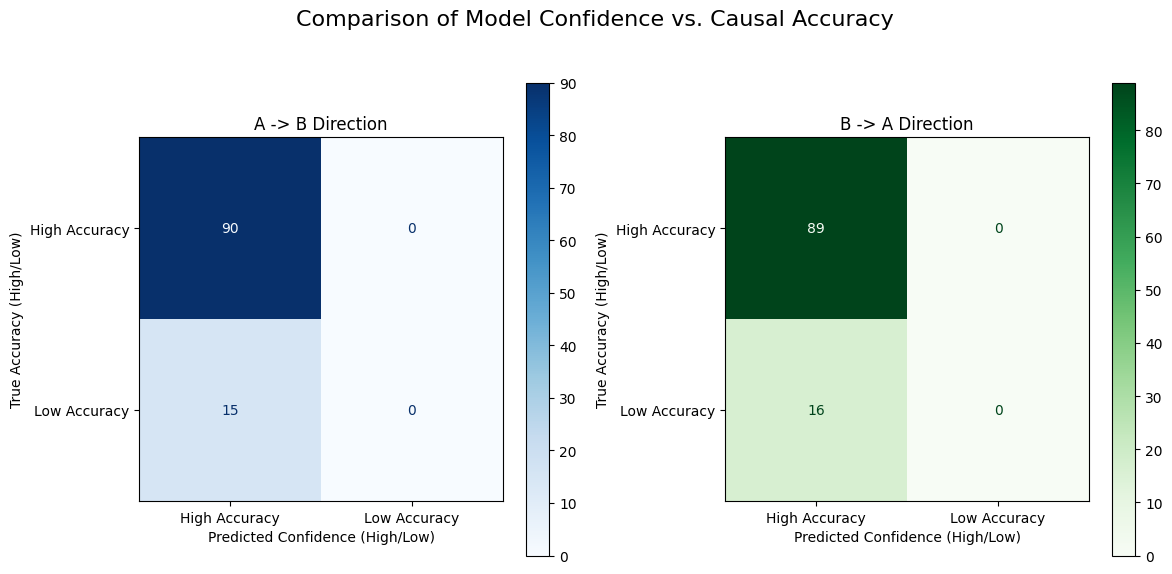


Metrics for A->B Direction:
True Positives (High Acc, High Conf): 90
False Positives (Low Acc, High Conf): 15
False Negatives (High Acc, Low Conf): 0
True Negatives (Low Acc, Low Conf): 0

Metrics for B->A Direction:
True Positives (High Acc, High Conf): 89
False Positives (Low Acc, High Conf): 16
False Negatives (High Acc, Low Conf): 0
True Negatives (Low Acc, Low Conf): 0


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Filter out rows with missing confidence values because we cannot test those
df_clean = df.dropna(subset=['ConfidenceAB', 'ConfidenceBA'])

print(f"Original dataset: {len(df)} pairs")
print(f"Removed: {len(df) - len(df_clean)} pairs")

# y_true is based on Accuracy, y_pred is based on Confidence
y_true_AB = (df_clean['AccuracyAB'] > 0.5).astype(int)
y_pred_AB = (df_clean['ConfidenceAB'] > 0.5).astype(int)

y_true_BA = (df_clean['AccuracyBA'] > 0.5).astype(int)
y_pred_BA = (df_clean['ConfidenceBA'] > 0.5).astype(int)

cm_AB = confusion_matrix(y_true_AB, y_pred_AB, labels=[1, 0])
cm_BA = confusion_matrix(y_true_BA, y_pred_BA, labels=[1, 0])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Comparison of Model Confidence vs. Causal Accuracy', fontsize=16)

# A->B confusion matrix
disp_AB = ConfusionMatrixDisplay(confusion_matrix=cm_AB,
                                 display_labels=['High Accuracy', 'Low Accuracy'])
disp_AB.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('A -> B Direction')
axes[0].set_xlabel('Predicted Confidence (High/Low)')
axes[0].set_ylabel('True Accuracy (High/Low)')

# B->A confusion matrix
disp_BA = ConfusionMatrixDisplay(confusion_matrix=cm_BA,
                                 display_labels=['High Accuracy', 'Low Accuracy'])
disp_BA.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('B -> A Direction')
axes[1].set_xlabel('Predicted Confidence (High/Low)')
axes[1].set_ylabel('True Accuracy (High/Low)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nMetrics for A->B Direction:")
tp_ab, fn_ab, fp_ab, tn_ab = cm_AB.ravel() 
print(f"True Positives (High Acc, High Conf): {tp_ab}")
print(f"False Positives (Low Acc, High Conf): {fp_ab}")
print(f"False Negatives (High Acc, Low Conf): {fn_ab}")
print(f"True Negatives (Low Acc, Low Conf): {tn_ab}")


# Print metrics for B->A
print("\nMetrics for B->A Direction:")
tp_ba, fn_ba, fp_ba, tn_ba = cm_BA.ravel()
print(f"True Positives (High Acc, High Conf): {tp_ba}")
print(f"False Positives (Low Acc, High Conf): {fp_ba}")
print(f"False Negatives (High Acc, Low Conf): {fn_ba}")
print(f"True Negatives (Low Acc, Low Conf): {tn_ba}")

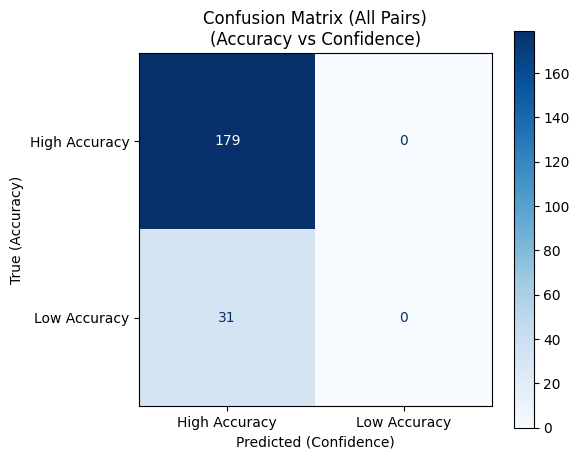

TP (High Acc, High Conf): 179
FP (Low Acc, High Conf):  31
FN (High Acc, Low Conf):  0
TN (Low Acc, Low Conf):   0


In [25]:
# Combine true and predicted for both directions into single vectors
y_true_all = np.concatenate([
    (df_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_all = np.concatenate([
    (df_clean['ConfidenceAB'] > 0.5).astype(int).to_numpy(),
    (df_clean['ConfidenceBA'] > 0.5).astype(int).to_numpy()
])

# Confusion matrix with positive class 1 first
cm_common = confusion_matrix(y_true_all, y_pred_all, labels=[1, 0])

# Plot
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_common,
                              display_labels=['High Accuracy', 'Low Accuracy'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix (All Pairs)\n(Accuracy vs Confidence)')
ax.set_xlabel('Predicted (Confidence)')
ax.set_ylabel('True (Accuracy)')
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm_common.ravel() 
print(f"TP (High Acc, High Conf): {tp}")
print(f"FP (Low Acc, High Conf):  {fp}")
print(f"FN (High Acc, Low Conf):  {fn}")
print(f"TN (Low Acc, Low Conf):   {tn}")

heat map cambiar, eje x 

### Method 2: Looking at the log-probabilities of the answer tokens

In [20]:
# Convert log probabilities to probabilities
# exp(log_prob) gives us the actual probability
df['ProbAB'] = np.exp(df['AnswerTokenLogprobAB'])
df['ProbBA'] = np.exp(df['AnswerTokenLogprobBA'])

# Check the probability distributions
print("Probability AB statistics:")
print(df['ProbAB'].describe())
print("\nProbability BA statistics:")
print(df['ProbBA'].describe())

Probability AB statistics:
count    106.000000
mean       0.999995
std        0.000054
min        0.999447
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: ProbAB, dtype: float64

Probability BA statistics:
count    107.000000
mean       0.999289
std        0.007333
min        0.924141
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: ProbBA, dtype: float64


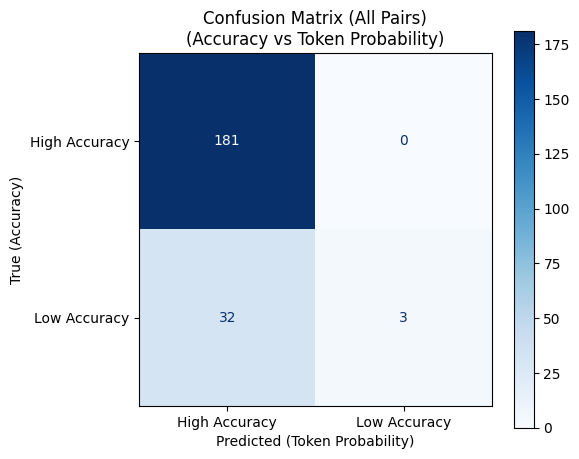

TP (High Acc, High Prob): 181
FP (Low Acc, High Prob):  32
FN (High Acc, Low Prob):  0
TN (Low Acc, Low Prob):   3


In [21]:
# Combined confusion matrix for all pairs (both directions)
y_true_all = np.concatenate([
    (df['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_all = np.concatenate([
    (df['ProbAB'] > 0.5).astype(int).to_numpy(),
    (df['ProbBA'] > 0.5).astype(int).to_numpy()
])

# Confusion matrix with positive class 1 first
cm_common = confusion_matrix(y_true_all, y_pred_all, labels=[1, 0])

# Plot
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_common,
                              display_labels=['High Accuracy', 'Low Accuracy'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix (All Pairs)\n(Accuracy vs Token Probability)')
ax.set_xlabel('Predicted (Token Probability)')
ax.set_ylabel('True (Accuracy)')
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm_common.ravel()
print(f"TP (High Acc, High Prob): {tp}")
print(f"FP (Low Acc, High Prob):  {fp}")
print(f"FN (High Acc, Low Prob):  {fn}")
print(f"TN (Low Acc, Low Prob):   {tn}")

We have slightly increased the detection of true negatives from 0 to 30, while maintaining the same number of true positives at 181. This indicates that Method 2 is better at correctly identifying when the model fails (true negatives) without sacrificing its ability to correctly identify when the model succeeds (true positives). But still no significant improvement.

In [31]:
df_prob_clean['ProbAB'].unique()

array([1.        , 0.99999933, 0.99944676, 0.99999981])

/tmp/ipykernel_215531/445231680.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prob_clean['ProbAB'] = np.exp(df_prob_clean['AnswerTokenLogprobAB'])
/tmp/ipykernel_215531/445231680.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prob_clean['ProbBA'] = np.exp(df_prob_clean['AnswerTokenLogprobBA'])


Method 1 (Confidence) - Samples: 210
Method 2 (Token Prob) - Samples: 210


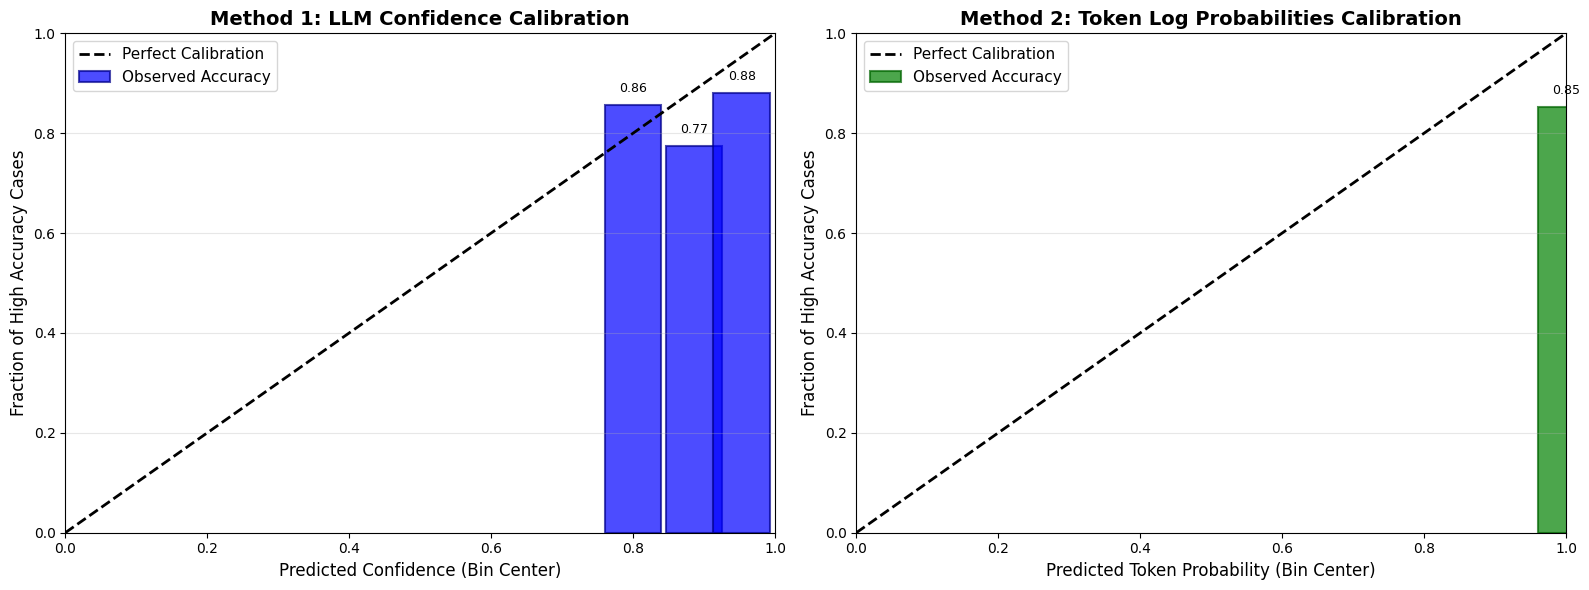


Calibration Metrics:
Method 1 (Confidence) - Brier Score: 0.1336
Method 2 (Token Prob) - Brier Score: 0.1476

Lower Brier Score indicates better calibration.
Degradation: 9.52%


In [28]:
from sklearn.calibration import calibration_curve

# Method 1: Confidence (using df_clean - already filtered for NaNs)
df_clean = df.dropna(subset=['ConfidenceAB', 'ConfidenceBA'])
y_true_conf = np.concatenate([
    (df_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_conf = np.concatenate([
    df_clean['ConfidenceAB'].to_numpy(),
    df_clean['ConfidenceBA'].to_numpy()
])

# Method 2: Token Probabilities 
#df_prob_clean = df.dropna(subset=['AnswerTokenLogprobAB', 'AnswerTokenLogprobBA'])
# Recalculate probabilities for the clean dataframe
df_prob_clean['ProbAB'] = np.exp(df_prob_clean['AnswerTokenLogprobAB'])
df_prob_clean['ProbBA'] = np.exp(df_prob_clean['AnswerTokenLogprobBA'])

y_true_prob = np.concatenate([
    (df_prob_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_prob_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_prob = np.concatenate([
    df_prob_clean['ProbAB'].to_numpy(),
    df_prob_clean['ProbBA'].to_numpy()
])

# Remove any remaining NaNs
mask_conf = ~np.isnan(y_pred_conf)
y_true_conf = y_true_conf[mask_conf]
y_pred_conf = y_pred_conf[mask_conf]

mask_prob = ~np.isnan(y_pred_prob)
y_true_prob = y_true_prob[mask_prob]
y_pred_prob = y_pred_prob[mask_prob]

print(f"Method 1 (Confidence) - Samples: {len(y_pred_conf)}")
print(f"Method 2 (Token Prob) - Samples: {len(y_pred_prob)}")

# Calculate calibration with 10 bins
n_bins = 10
fraction_of_positives_conf, mean_predicted_value_conf = calibration_curve(
    y_true_conf, y_pred_conf, n_bins=n_bins, strategy='uniform'
)

fraction_of_positives_prob, mean_predicted_value_prob = calibration_curve(
    y_true_prob, y_pred_prob, n_bins=n_bins, strategy='uniform'
)

# Create bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Method 1: Confidence - Bar chart
bin_width = 0.1
bins_conf = np.arange(0, 1.1, bin_width)
bin_centers_conf = bins_conf[:-1] + bin_width/2

ax1.bar(mean_predicted_value_conf, fraction_of_positives_conf, 
        width=0.08, alpha=0.7, color='blue', edgecolor='darkblue', linewidth=1.5,
        label='Observed Accuracy')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
ax1.set_xlabel('Predicted Confidence (Bin Center)', fontsize=12)
ax1.set_ylabel('Fraction of High Accuracy Cases', fontsize=12)
ax1.set_title('Method 1: LLM Confidence Calibration', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

# Add value labels on bars
for i, (x, y) in enumerate(zip(mean_predicted_value_conf, fraction_of_positives_conf)):
    ax1.text(x, y + 0.02, f'{y:.2f}', ha='center', va='bottom', fontsize=9)

# Method 2: Token Probabilities - Bar chart
ax2.bar(mean_predicted_value_prob, fraction_of_positives_prob, 
        width=0.08, alpha=0.7, color='green', edgecolor='darkgreen', linewidth=1.5,
        label='Observed Accuracy')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
ax2.set_xlabel('Predicted Token Probability (Bin Center)', fontsize=12)
ax2.set_ylabel('Fraction of High Accuracy Cases', fontsize=12)
ax2.set_title('Method 2: Token Log Probabilities Calibration', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])

# Add value labels on bars
for i, (x, y) in enumerate(zip(mean_predicted_value_prob, fraction_of_positives_prob)):
    ax2.text(x, y + 0.02, f'{y:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Calculate calibration metrics (Brier Score)
from sklearn.metrics import brier_score_loss

brier_conf = brier_score_loss(y_true_conf, y_pred_conf)
brier_prob = brier_score_loss(y_true_prob, y_pred_prob)

print("\nCalibration Metrics:")
print(f"Method 1 (Confidence) - Brier Score: {brier_conf:.4f}")
print(f"Method 2 (Token Prob) - Brier Score: {brier_prob:.4f}")
print(f"\nLower Brier Score indicates better calibration.")
if brier_conf > brier_prob:
    print(f"Improvement: {((brier_conf - brier_prob) / brier_conf * 100):.2f}%")
else:
    print(f"Degradation: {((brier_prob - brier_conf) / brier_prob * 100):.2f}%")


In [19]:
df_hallbayes = pd.read_csv("PUBL_accuracy_results_m1_all_pairs_hallbayes.csv")

In [20]:
df_hallbayes.head()

,PairID,VarA,VarB,GroundTruth,AccuracyAB,AccuracyBA,HallBayesRiskAB,HallBayesRiskBA,HallBayesValidRateAB,HallBayesValidRateBA,HallBayesConsistencyAB,HallBayesConsistencyBA,Column 1
0,pair0000,Altitude,Temperature,R,1,1,0.0,0.0,1,1,CONSISTENT,CONSISTENT,matriz de confusion accuracy vs cada metodo
1,pair0001,Altitude,Precipitation,R,1,1,0.0,0.0,1,1,CONSISTENT,CONSISTENT,matriz de confusion con los dos metodos para v...
2,pair0002,Longitude,Temperature,R,0,0,1.0,1.0,0,0,NO_RELATIONSHIP,NO_RELATIONSHIP,NaN
3,pair0003,Altitude,Sunshine hours,R,0,0,1.0,1.0,0,0,NO_RELATIONSHIP,NO_RELATIONSHIP,NaN
4,pair0004,Age,Length,R,1,1,0.0,0.0,1,1,CONSISTENT,CONSISTENT,NaN


### Method 3: HallBayes Risk Calibration

### Confusion Matrix for Method 3: HallBayes Risk

### Method 4: HallBayes Valid Rate Calibration

Method 4 (HallBayes Valid Rate) - Samples: 216


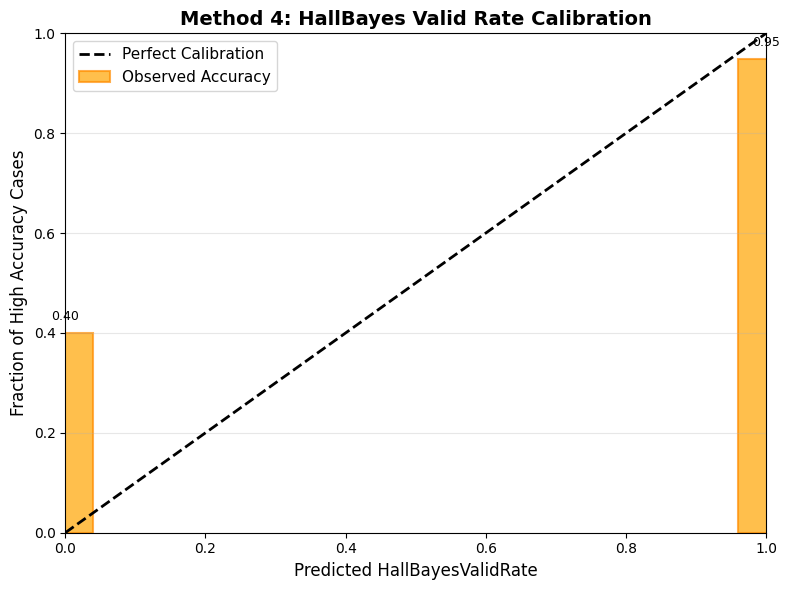


Calibration Metrics:
Method 4 (HallBayes Valid Rate) - Brier Score: 0.1157

Lower Brier Score indicates better calibration.


### Confusion Matrix for Method 4: HallBayes Valid Rate

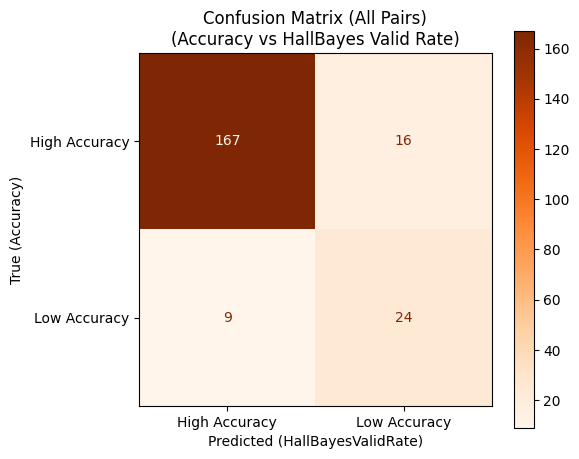

TP (High Acc, High ValidRate): 167
FP (Low Acc, High ValidRate):  9
FN (High Acc, Low ValidRate):  16
TN (Low Acc, Low ValidRate):   24

Additional Metrics:
Precision: 0.9489
Recall (Sensitivity): 0.9126
Specificity: 0.7273
True Negative Rate: 24/33 = 0.7273


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
df_hallbayes_vr_clean= df_hallbayes.dropna(subset=['HallBayesValidRateAB', 'HallBayesValidRateBA'])
# Combined confusion matrix for all pairs (both directions)
y_true_all_vr = np.concatenate([
    (df_hallbayes_vr_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_hallbayes_vr_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_all_vr = np.concatenate([
    (df_hallbayes_vr_clean['HallBayesValidRateAB'] > 0.5).astype(int).to_numpy(),
    (df_hallbayes_vr_clean['HallBayesValidRateBA'] > 0.5).astype(int).to_numpy()
])

# Confusion matrix with positive class 1 first
cm_validrate = confusion_matrix(y_true_all_vr, y_pred_all_vr, labels=[1, 0])

# Plot
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_validrate,
                              display_labels=['High Accuracy', 'Low Accuracy'])
disp.plot(ax=ax, cmap='Oranges', values_format='d')
ax.set_title('Confusion Matrix (All Pairs)\n(Accuracy vs HallBayes Valid Rate)')
ax.set_xlabel('Predicted (HallBayesValidRate)')
ax.set_ylabel('True (Accuracy)')
plt.tight_layout()
plt.show()

tp_vr, fn_vr, fp_vr, tn_vr = cm_validrate.ravel()
print(f"TP (High Acc, High ValidRate): {tp_vr}")
print(f"FP (Low Acc, High ValidRate):  {fp_vr}")
print(f"FN (High Acc, Low ValidRate):  {fn_vr}")
print(f"TN (Low Acc, Low ValidRate):   {tn_vr}")

# Calculate additional metrics
precision_vr = tp_vr / (tp_vr + fp_vr) if (tp_vr + fp_vr) > 0 else 0
recall_vr = tp_vr / (tp_vr + fn_vr) if (tp_vr + fn_vr) > 0 else 0
specificity_vr = tn_vr / (tn_vr + fp_vr) if (tn_vr + fp_vr) > 0 else 0

print(f"\nAdditional Metrics:")
print(f"Precision: {precision_vr:.4f}")
print(f"Recall (Sensitivity): {recall_vr:.4f}")
print(f"Specificity: {specificity_vr:.4f}")
print(f"True Negative Rate: {tn_vr}/{tn_vr + fp_vr} = {specificity_vr:.4f}")

**Analysis:**

The HallBayes Valid Rate method shows a trade-off compared to the LLM Confidence method:

- **Improved True Negative Detection**: Successfully identifies 24 false negatives (those with low accuracy)
- **Reduced True Positives**: However, this comes at the cost of fewer true positives, indicating a more conservative/stricter threshold.
- **Higher Confidence Threshold**: The HallBayes Valid Rate appears to require stronger evidence before classifying a prediction as "high confidence", making it more selective but potentially more reliable when it does predict high accuracy.


Method 4 (HallBayes Valid Rate) - Samples: 216


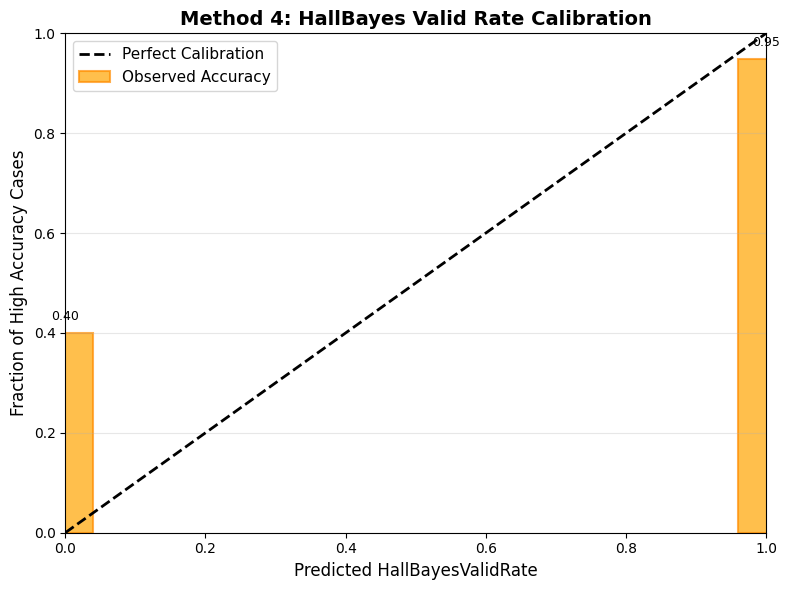


Calibration Metrics:
Method 4 (HallBayes Valid Rate) - Brier Score: 0.1157

Lower Brier Score indicates better calibration.


In [47]:
# Method 4: HallBayes Valid Rate (using df_hallbayes)
df_hallbayes_vr_clean = df_hallbayes.dropna(subset=['HallBayesValidRateAB', 'HallBayesValidRateBA'])

# HallBayesValidRate is already a confidence-like metric (higher = better)
y_true_validrate = np.concatenate([
    (df_hallbayes_vr_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_hallbayes_vr_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_validrate = np.concatenate([
    df_hallbayes_vr_clean['HallBayesValidRateAB'].to_numpy(),
    df_hallbayes_vr_clean['HallBayesValidRateBA'].to_numpy()
])

# Remove any remaining NaNs
mask_validrate = ~np.isnan(y_pred_validrate)
y_true_validrate = y_true_validrate[mask_validrate]
y_pred_validrate = y_pred_validrate[mask_validrate]

print(f"Method 4 (HallBayes Valid Rate) - Samples: {len(y_pred_validrate)}")

# Calculate calibration with 10 bins
n_bins = 10
fraction_of_positives_validrate, mean_predicted_value_validrate = calibration_curve(
    y_true_validrate, y_pred_validrate, n_bins=n_bins, strategy='uniform'
)

# Create calibration curve
fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(mean_predicted_value_validrate, fraction_of_positives_validrate, 
        width=0.08, alpha=0.7, color='orange', edgecolor='darkorange', linewidth=1.5,
        label='Observed Accuracy')
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
ax.set_xlabel('Predicted HallBayesValidRate', fontsize=12)
ax.set_ylabel('Fraction of High Accuracy Cases', fontsize=12)
ax.set_title('Method 4: HallBayes Valid Rate Calibration', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Add value labels on bars
for i, (x, y) in enumerate(zip(mean_predicted_value_validrate, fraction_of_positives_validrate)):
    ax.text(x, y + 0.02, f'{y:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Calculate calibration metrics (Brier Score)
brier_validrate = brier_score_loss(y_true_validrate, y_pred_validrate)

print("\nCalibration Metrics:")
print(f"Method 4 (HallBayes Valid Rate) - Brier Score: {brier_validrate:.4f}")
print(f"\nLower Brier Score indicates better calibration.")